# Graph II

In [1]:
from typing import TypedDict, List
from langgraph.graph import StateGraph 

In [2]:
# 目标是处理和加工多个不同的输入
class AgentState(TypedDict):
    values: List[int]
    name: str 
    result: str 

In [ ]:
# 构建节点，需要传入状态，并返回更新后的状态
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)

    state["result"] = f'Hi there {state["name"]}! Your sum = {sum(state["values"])}'   # 内层用双引号，外层用单引号

    print(state)
    return state

In [5]:
# 初始化图，并传入状态模式
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")    # Set the starting node
graph.set_finish_point("processor")   # Set the ending node

app = graph.compile()   # Compiling the graph

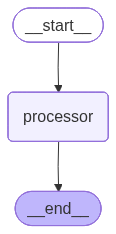

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
# 必须要先编译图，把编译后的结果存储在一个变量app中，再调用
answers = app.invoke({"values": [1,2,3,4], "name": "Steve"})    # 没有将 result 作为输入传入，LangGraph会自动将其设置为一个空值

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [8]:
print(answers["result"])

Hi there Steve! Your sum = 10
